<a href="https://colab.research.google.com/github/Melisaoktavia/Pratikum1_Minggu5/blob/main/PCD_MGG5_P1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PRAKTIKUM 5.1


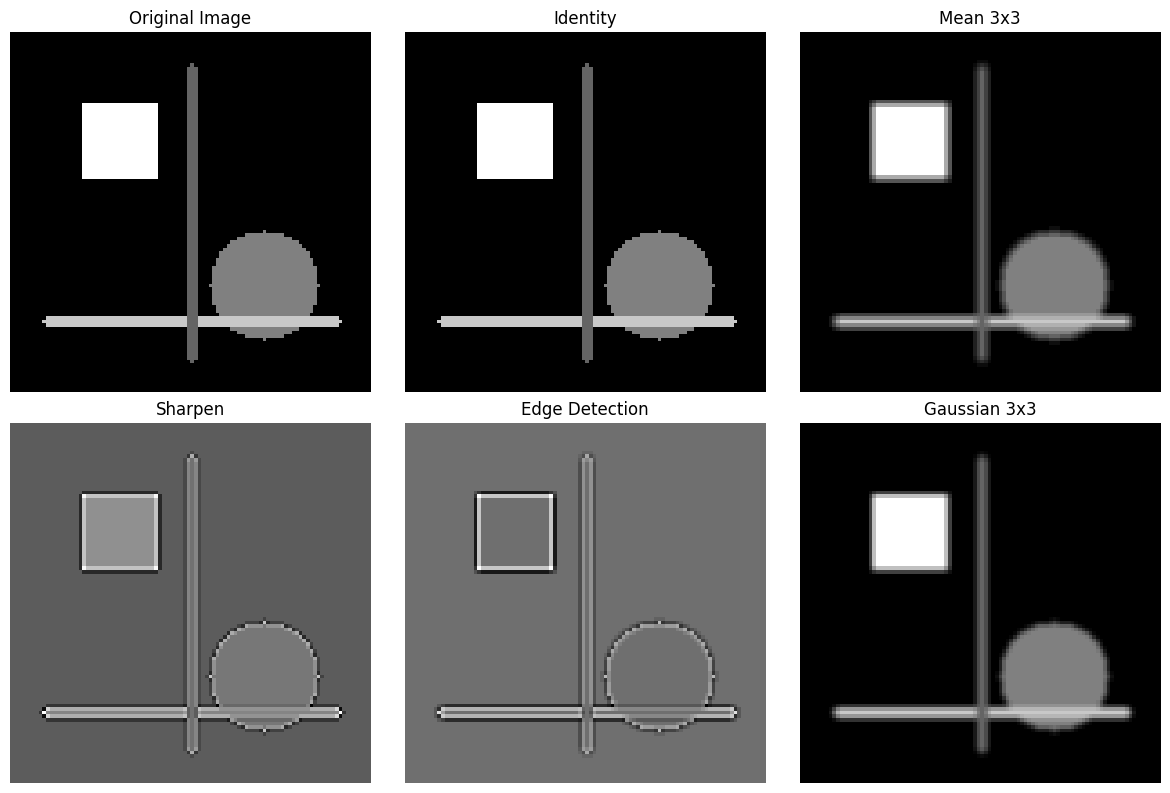

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def manual_convolution(image, kernel):

    img_h, img_w = image.shape
    kernel_h, kernel_w = kernel.shape

    pad_h = kernel_h // 2
    pad_w = kernel_w // 2

    padded_img = np.zeros((img_h + 2*pad_h, img_w + 2*pad_w))
    padded_img[pad_h:pad_h+img_h, pad_w:pad_w+img_w] = image

    output = np.zeros_like(image, dtype=np.float32)

    for i in range(img_h):
        for j in range(img_w):
            region = padded_img[i:i+kernel_h, j:j+kernel_w]
            output[i, j] = np.sum(region * kernel)

    return output


def create_test_pattern(size=100):

    img = np.zeros((size, size), dtype=np.float32)

    cv2.rectangle(img, (20,20), (40,40), 255, -1)
    cv2.circle(img, (70,70), 15, 128, -1)
    cv2.line(img, (10,80), (90,80), 200, 2)
    cv2.line(img, (50,10), (50,90), 100, 2)

    return img


kernels = {

    'Identity': np.array([[0,0,0],
                          [0,1,0],
                          [0,0,0]]),

    'Mean 3x3': np.array([[1,1,1],
                          [1,1,1],
                          [1,1,1]])/9,

    'Sharpen': np.array([[0,-1,0],
                         [-1,5,-1],
                         [0,-1,0]]),

    'Edge Detection': np.array([[-1,-1,-1],
                                [-1,8,-1],
                                [-1,-1,-1]]),

    'Gaussian 3x3': np.array([[1,2,1],
                              [2,4,2],
                              [1,2,1]])/16
}

print("PRAKTIKUM 5.1")

test_image = create_test_pattern()

fig, axes = plt.subplots(2,3, figsize=(12,8))
axes = axes.ravel()

axes[0].imshow(test_image, cmap='gray')
axes[0].set_title("Original Image")
axes[0].axis('off')

for idx,(name,kernel) in enumerate(kernels.items()):

    result = manual_convolution(test_image, kernel)

    axes[idx+1].imshow(result, cmap='gray')
    axes[idx+1].set_title(name)
    axes[idx+1].axis('off')

plt.tight_layout()
plt.show()